<a href="https://colab.research.google.com/github/drizcode4350/logistic_regression_project/blob/main/project2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Steps:

1. Preprocessing + EDA + Feature Selection
2. Extract input and output columns.
3. Scale the values.
4. Train test split.
5. Train the model.
6. Evaluate the model / model selection
7. Deploy the model

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv('/content/modified_placement_data.csv')

In [ ]:
df.head()

,cgpa,iq,placement
0,"6,8",123.0,Yes
1,"5,9",106.0,No
2,"5,3",121.0,No
3,"7,4",132.0,Yes
4,"5,8",142.0,No


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   cgpa       95 non-null     object 
 1   iq         100 non-null    float64
 2   placement  100 non-null    object 
dtypes: float64(1), object(2)
memory usage: 2.5+ KB


In [ ]:
df=df.dropna()

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 95 entries, 0 to 99
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   cgpa       95 non-null     object 
 1   iq         95 non-null     float64
 2   placement  95 non-null     object 
dtypes: float64(1), object(2)
memory usage: 3.0+ KB


In [ ]:
df['placement']=df['placement'].replace({'Yes':1, 'No':0})

/tmp/ipykernel_2026/2842610980.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['placement']=df['placement'].replace({'Yes':1, 'No':0})


In [ ]:
df.head()

,cgpa,iq,placement
0,"6,8",123.0,1
1,"5,9",106.0,0
2,"5,3",121.0,0
3,"7,4",132.0,1
4,"5,8",142.0,0


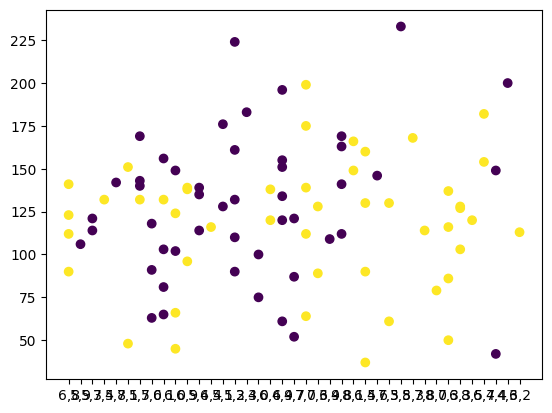

In [ ]:
plt.scatter(df['cgpa'], df['iq'], c=df['placement'])

In [ ]:
x=df.iloc[:,:2]
x.head()

,cgpa,iq
0,"6,8",123.0
1,"5,9",106.0
2,"5,3",121.0
3,"7,4",132.0
4,"5,8",142.0


In [ ]:
y=df.iloc[:,-1]
y.head()

,placement
0,1
1,0
2,0
3,1
4,0


In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test=train_test_split(x,y, test_size=0.1)

In [ ]:
x_train

,cgpa,iq
14,"6,1",103.0
25,"5,0",91.0
48,"6,6",138.0
31,"3,9",109.0
2,"5,3",121.0
...,...,...
59,"4,8",112.0
66,"6,9",96.0
58,"8,0",79.0
55,"7,8",114.0


In [ ]:
print(x_train.dtypes)

cgpa     object
iq      float64
dtype: object


In [ ]:
for col in x_train.columns:
  if x_train[col].dtype=='object':
    print(col)
    print(x_train[col].unique()[:10])

cgpa
['6,1' '5,0' '6,6' '3,9' '5,3' '5,4' '6,3' '4,4' '7,1' '4,7']


In [ ]:
x_train=x_train.replace(',','.', regex=True)
x_train=x_train.astype(float)

In [ ]:
print(x_test.dtypes)

cgpa     object
iq      float64
dtype: object


In [ ]:
for col in x_test.columns:
  if x_test[col].dtype=='object':
    print(col)
    print(x_test[col].unique()[:10])

cgpa
['5,7' '7,3' '6,1' '5,9' '5,2' '6,3' '7,4' '4,8' '6,5']


In [ ]:
x_test=x_test.replace(',','.', regex=True)
x_test=x_test.astype(float)

In [ ]:
y_train

,placement
14,0
25,0
48,1
31,0
2,0
...,...
59,0
66,1
58,1
55,1


In [ ]:
x_test

,cgpa,iq
87,"5,7",132.0
72,"7,3",116.0
71,"6,1",132.0
1,"5,9",106.0
28,"5,2",90.0
98,"6,3",103.0
3,"7,4",132.0
75,"4,8",169.0
56,"6,1",65.0
82,"6,5",37.0


In [ ]:
y_test

,placement
87,1
72,1
71,1
1,0
28,0
98,1
3,1
75,0
56,0
82,1


In [ ]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train=sc.fit_transform(x_train)

In [ ]:
x_train

array([[ 0.10810088, -0.55433528],
       [-0.81918649, -0.85461249],
       [ 0.52959514,  0.32147325],
       [-1.74647386, -0.40419667],
       [-0.56628993, -0.10391947],
       [-0.48199108,  0.24640395],
       [ 0.27669858,  0.07124224],
       [ 0.52959514, -0.12894257],
       [-0.81918649, -0.17898877],
       [-1.3249796 , -2.08074442],
       [ 0.9510894 , -1.93060582],
       [-1.07208305, -0.95470489],
       [-0.65058879,  2.47345991],
       [ 0.44529629,  0.12128844],
       [-0.48199108, -0.27908117],
       [ 0.02380203, -0.57935838],
       [ 0.44529629, -0.87963559],
       [-2.25226697,  1.44751278],
       [ 0.69819284,  0.39654255],
       [-0.73488764,  0.07124224],
       [ 0.44529629,  0.87198146],
       [ 2.13127333, -0.12894257],
       [ 0.02380203, -2.00567512],
       [ 0.86679055, -0.32912737],
       [-1.66217501, -1.2549821 ],
       [ 0.69819284, -0.05387326],
       [-2.08366927,  2.69866782],
       [-0.22909453,  1.09718937],
       [ 0.02380203,

In [ ]:
x_test=sc.transform(x_test)

In [ ]:
x_test

array([[-0.22909453,  0.17133464],
       [ 1.1196871 , -0.22903497],
       [ 0.10810088,  0.17133464],
       [-0.06049682, -0.47926598],
       [-0.65058879, -0.87963559],
       [ 0.27669858, -0.55433528],
       [ 1.20398595,  0.17133464],
       [-0.98778419,  1.09718937],
       [ 0.10810088, -1.50521311],
       [ 0.44529629, -2.20585993]])

In [ ]:
from sklearn.linear_model import LogisticRegression
cif=LogisticRegression()
cif.fit(x_train, y_train)

LogisticRegression()

In [ ]:
y_pred=cif.predict(x_test)
y_pred

array([0, 1, 1, 0, 0, 1, 1, 0, 1, 1])

In [ ]:
y_test

,placement
87,1
72,1
71,1
1,0
28,0
98,1
3,1
75,0
56,0
82,1


In [ ]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test, y_pred))

0.8


<Axes: >

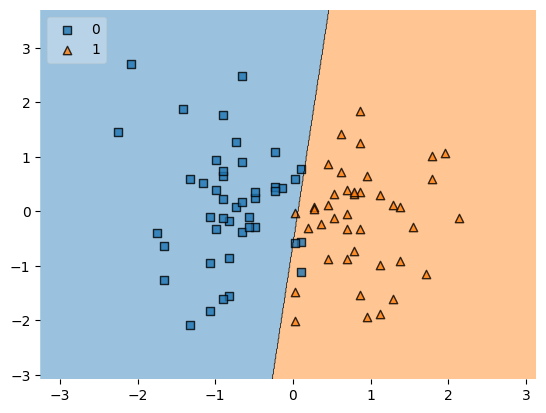

In [ ]:
from mlxtend.plotting import plot_decision_regions
plot_decision_regions(x_train, y_train.values, clf=cif, legend=2)

In [ ]:
import pickle
pickle.dump(cif, open('model.pkl', 'wb'))